# I. Régression logistique

## 1. Import des librairies et chargement du split

In [1]:
import numpy as np
import pandas as pd

from joblib import load
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
    brier_score_loss
)
import matplotlib.pyplot as plt

# Load
preprocessor = load("artifacts/preprocessor.joblib")
X_train, X_val, X_test, y_train, y_val, y_test = load("artifacts/splits_raw.joblib")

# Transform
X_train_final = preprocessor.transform(X_train)
X_val_final   = preprocessor.transform(X_val)
X_test_final  = preprocessor.transform(X_test)

# Feature names (utile pour interpréter la logreg)
feature_names = preprocessor.get_feature_names_out()

print(X_train_final.shape, X_val_final.shape, X_test_final.shape)


(27126, 42) (9042, 42) (9043, 42)


Les données ont été chargées depuis le notebook de preprocessing, puis transformées à l’aide du preprocessor appris uniquement sur l’ensemble d’entraînement.

- **Train** : 27 126 observations  
- **Validation** : 9 042 observations  
- **Test** : 9 043 observations  
- **Nombre de variables après encodage** : 42

## 2. Définition de la fonction d’évaluation

In [2]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
    brier_score_loss
)

def evaluate_probas(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "brier": brier_score_loss(y_true, y_proba),
        "f1": f1_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "threshold": threshold,
    }

## 3. Baseline Logistic Regression (sans tuning)
### 3.1 Entrainement du modèle 

In [3]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=500,              # nombre max d’itérations pour converger
    class_weight="balanced",   # gère le déséquilibre
    solver="lbfgs"             # algorithme d’optimisation standard
)

logreg.fit(X_train_final, y_train)

proba_train = logreg.predict_proba(X_train_final)[:, 1]
proba_val   = logreg.predict_proba(X_val_final)[:, 1]
proba_test  = logreg.predict_proba(X_test_final)[:, 1]

results = pd.DataFrame([
    {"split": "train", **evaluate_probas(y_train, proba_train, 0.5)},
    {"split": "val",   **evaluate_probas(y_val,   proba_val,   0.5)},
    {"split": "test",  **evaluate_probas(y_test,  proba_test,  0.5)},
])

results

,split,roc_auc,pr_auc,brier,f1,recall,precision,threshold
0,train,0.768214,0.401013,0.184385,0.378298,0.639458,0.268599,0.5
1,val,0.773366,0.415809,0.182765,0.370927,0.629490,0.262929,0.5
2,test,0.771869,0.411788,0.182940,0.380634,0.646503,0.269716,0.5


- Pas d’overfitting flagrant
- Performance réaliste
- Bonne baseline

### Performances de la régression logistique (baseline, sans tuning)

Indique une bonne capacité de généralisation du modèle

- **ROC AUC ≈ 0.77** :  
  Le modèle discrimine correctement les clients susceptibles de souscrire, nettement au-dessus du hasard (0.5).

- **PR AUC ≈ 0.41** :  
  La performance reste correcte dans un contexte de classes déséquilibrées, ce qui est plus informatif que la ROC seule.

- **Brier score ≈ 0.18** :  
  Les probabilités prédites sont raisonnablement calibrées, mais perfectibles.

- **Recall élevé (~0.64)** :  
  Le modèle détecte une grande partie des souscripteurs, ce qui est cohérent avec un objectif commercial.

- **Precision modérée (~0.27)** :  
  De nombreux faux positifs subsistent, ce qui est attendu avec un seuil par défaut à 0.5.

Aucune dégradation significative n’est observée entre train et validation, suggérant l’absence d’overfitting notable.


Recall= TP/(TP+FN)
Precision = TP/(TP+FP)

### 3.2 Diagnostic : ROC/PR + histogrammes + confusion matrix

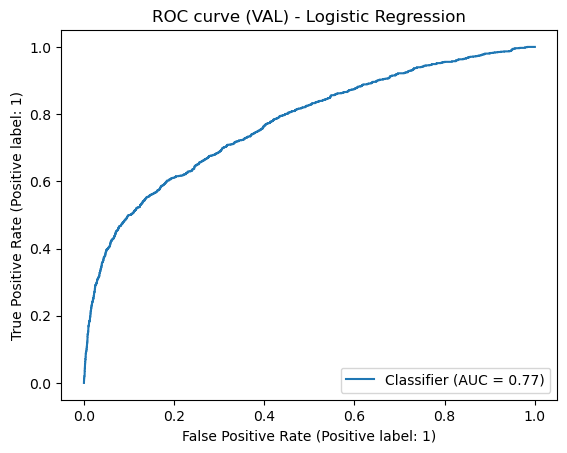

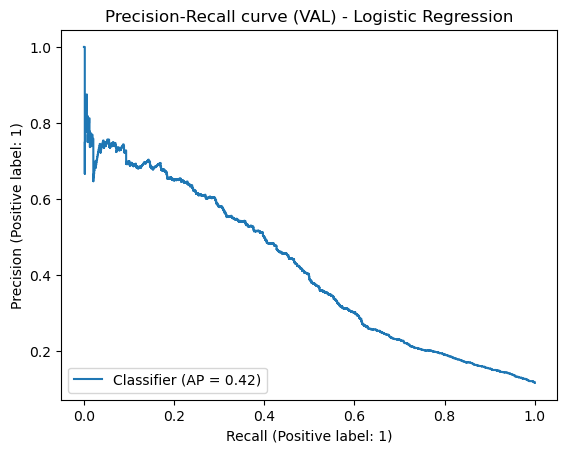

In [4]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

RocCurveDisplay.from_predictions(y_val, proba_val)
plt.title("ROC curve (VAL) - Logistic Regression")
plt.show()

PrecisionRecallDisplay.from_predictions(y_val, proba_val)
plt.title("Precision-Recall curve (VAL) - Logistic Regression")
plt.show()

### Courbe ROC (ensemble de validation)

La courbe ROC montre une bonne séparation globale entre les classes positives et négatives sur l’ensemble de validation.

AUC = 0.77 donc le modèle attribue un score plus élevé à un individu positif qu’à un individu négatif dans 77 % des cas.
La courbe étant nettement au-dessus de la diagonale, la régression logistique constitue une baseline solide avant toute phase de calibration ou de modélisation plus complexe.

### Courbe Precision–Recall (ensemble de validation)

Axes
x = Recall = parmi les vrais positifs, combien j’en retrouve ?
y = Precision = parmi ceux que je prédis positifs, combien sont vraiment positifs ?

Cependant, la courbe Precision–Recall révèle les limites du modèle dans un contexte de classes déséquilibrées. La précision décroît rapidement lorsque le rappel augmente, montrant qu’identifier davantage de positifs s’accompagne d’un nombre important de faux positifs.
On observe une forte précision pour les premiers niveaux de rappel, puis une dégradation progressive lorsque le seuil diminue.  
Average Precision = 0.42 --> pas mal

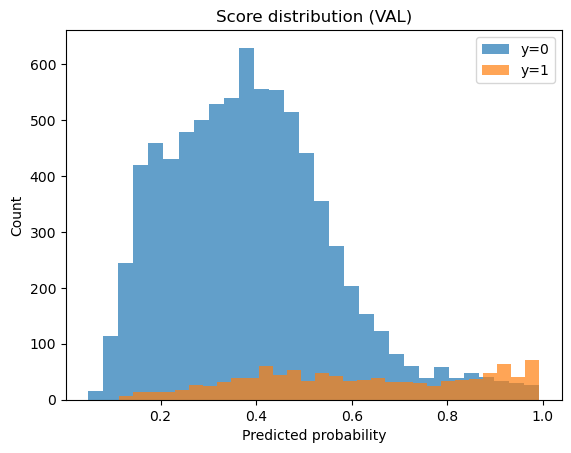

In [5]:
plt.figure()
plt.hist(proba_val[y_val==0], bins=30, alpha=0.7, label="y=0")
plt.hist(proba_val[y_val==1], bins=30, alpha=0.7, label="y=1")
plt.title("Score distribution (VAL)")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.legend()
plt.show()

### Distribution des probabilités prédites (validation)

La distribution des scores montre une séparation partielle entre les classes :

- Les observations négatives (y=0) sont majoritairement concentrées autour de probabilités intermédiaires.
- Les observations positives (y=1) sont décalées vers des probabilités plus élevées, mais avec un recouvrement significatif.

Cette superposition indique que certaines décisions restent ambiguës.

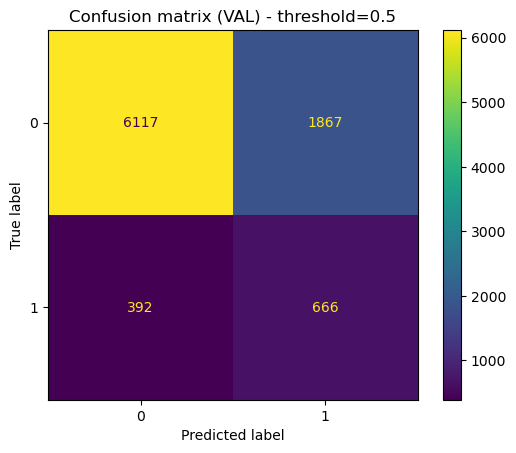

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

y_val_pred = (proba_val >= 0.5).astype(int)
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)
plt.title("Confusion matrix (VAL) - threshold=0.5")
plt.show()

### Matrice de confusion (validation, seuil = 0.5)

Avec un seuil de décision fixé à 0.5 :

- Le modèle identifie correctement une majorité de clients non souscripteurs (TN élevés).
- Le nombre de faux positifs reste important, traduisant une stratégie orientée vers le rappel.
- Le nombre de faux négatifs est relativement limité, ce qui est souhaitable dans un contexte où manquer un client potentiel est coûteux.

Cette matrice confirme que le seuil par défaut privilégie la détection des positifs au détriment de la précision

## 4. L'optimisation (Tuning) du modèle

Le levier principal est l'hyperparamètre C. un C petit simplifie le modèle (évite le sur-apprentissage), un C grand permet au modèle de mieux coller aux données d'entraînement. Nous allons utiliser une GridSearchCV pour trouver la valeur de C qui maximise l'AUC. 

In [7]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# On utilise l'AUC comme métrique principale de sélection
grid_search = GridSearchCV(
    LogisticRegression(max_iter=500, class_weight="balanced", solver="lbfgs"),
    param_grid,
    scoring='roc_auc',
    cv=5, 
    n_jobs=-1
)

grid_search.fit(X_train_final, y_train)

# Extraction du meilleur modèle
best_logreg = grid_search.best_estimator_
print(f"Meilleur hyperparamètre trouvé : {grid_search.best_params_}")

# Évaluation du nouveau modèle sur le set de Validation
proba_val_tuned = best_logreg.predict_proba(X_val_final)[:, 1]
perf_tuned = evaluate_probas(y_val, proba_val_tuned, threshold=0.5)

# Comparaison avec la baseline
print("\n--- Comparaison Baseline vs Modèle Tuné (Validation) ---")
comparison_df = pd.DataFrame([
    {"Modèle": "Baseline (C=1.0)", **evaluate_probas(y_val, proba_val, 0.5)},
    {"Modèle": f"Optimisé (C={grid_search.best_params_['C']})", **perf_tuned}
])
display(comparison_df)

Meilleur hyperparamètre trouvé : {'C': 0.1}

--- Comparaison Baseline vs Modèle Tuné (Validation) ---


,Modèle,roc_auc,pr_auc,brier,f1,recall,precision,threshold
0,Baseline (C=1.0),0.773366,0.415809,0.182765,0.370927,0.629490,0.262929,0.5
1,Optimisé (C=0.1),0.773978,0.415908,0.183438,0.371373,0.635161,0.262398,0.5


On constate que les performances restent extrêmement proches de la baseline (gain de l'AUC de +0.0006). Cela indique que le modèle de régression logistique a atteint son "plateau" de performance sur ces données.

Stabilité : Le score de Brier (autour de 0.18) et les métriques de rappel/précision restent stables, confirmant que le modèle ne souffre pas de sur-apprentissage (overfitting).

# II. La calibration 

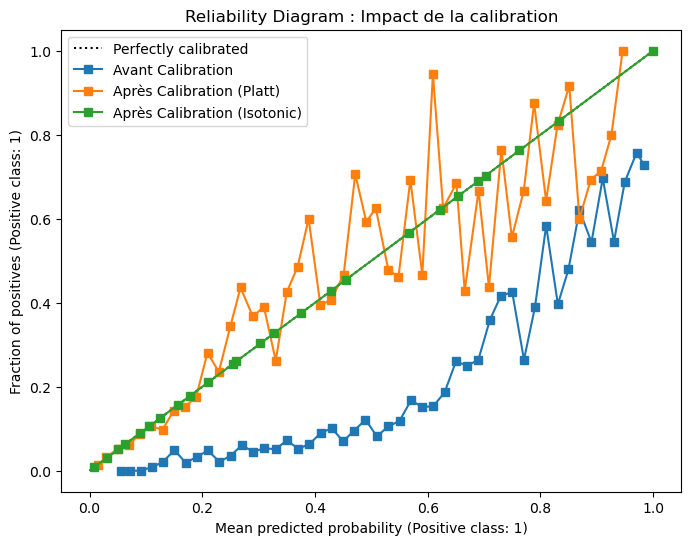

Brier Score AVANT       : 0.1834
Brier Score PLATT       : 0.0849
Brier Score ISOTONIC    : 0.0837


In [10]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

# On utilise 'prefit' car notre modèle est déjà entraîné
calibrated_logreg_sig = CalibratedClassifierCV(best_logreg, method='sigmoid', cv='prefit')
calibrated_logreg_sig.fit(X_val_final, y_val)
calibrated_logreg_iso = CalibratedClassifierCV(best_logreg, method='isotonic', cv='prefit')
calibrated_logreg_iso.fit(X_val_final, y_val)
proba_val_calibrated = calibrated_logreg_sig.predict_proba(X_val_final)[:, 1]
proba_val_calibrated_iso = calibrated_logreg_iso.predict_proba(X_val_final)[:, 1]
# 3. Affichage du Reliability Diagram (Avant vs Après)
fig, ax = plt.subplots(figsize=(8, 6))

CalibrationDisplay.from_predictions(y_val, proba_val_tuned, n_bins=50, name="Avant Calibration", ax=ax)
CalibrationDisplay.from_predictions(y_val, proba_val_calibrated, n_bins=50, name="Après Calibration (Platt)", ax=ax)
CalibrationDisplay.from_predictions(y_val, proba_val_calibrated_iso, n_bins=50, name="Après Calibration (Isotonic)", ax=ax)
ax.set_title("Reliability Diagram : Impact de la calibration")
plt.legend()
plt.show()

# 4. Comparaison du Brier Score
brier_before = evaluate_probas(y_val, proba_val_tuned, 0.5)['brier']
brier_platt = evaluate_probas(y_val, proba_val_calibrated, 0.5)['brier']
brier_iso = evaluate_probas(y_val, proba_val_calibrated_iso, 0.5)['brier']
print(f"Brier Score AVANT       : {brier_before:.4f}")
print(f"Brier Score PLATT       : {brier_platt:.4f}")
print(f"Brier Score ISOTONIC    : {brier_iso:.4f}")

Le Reliability Diagram : Avant calibration (bleue), le modèle était sur-confiant. Sa courbe se situait en dessous de la diagonale, ce qui signifie qu'il attribuait des probabilités de souscription beaucoup plus élevées que la réalité. Après l'application du Platt Scaling (orange), la courbe suit beaucoup plus fidèlement la diagonale : le modèle est désormais "honnête". La courbe Isotonic (en vert) est quasiment confondue avec la diagonale de perfection. Cela signifie que les probabilités prédites correspondent désormais presque exactement aux fréquences observées dans la réalité.

Nous retiendrons la version Isotonic pour la suite car elle offre la meilleure fiabilité statistique sur ce jeu de données.

Le Brier Score : La méthode Isotonic Regression obtient le meilleur score (0.0837), légèrement devant le Platt Scaling (0.0849). Les deux méthodes divisent par plus de deux l'erreur du modèle initial (0.1834).

# III. Choix du seuil optimal (Decision Threshold)

Les probabilités sont désormais fiables (calibrées avec Isotonic), le seuil par défaut de 0.5 n'est plus forcément le meilleur. Nous allons chercher le seuil qui équilibre la Précision (ne pas appeler n'importe qui) et le Rappel (ne rater aucun client).

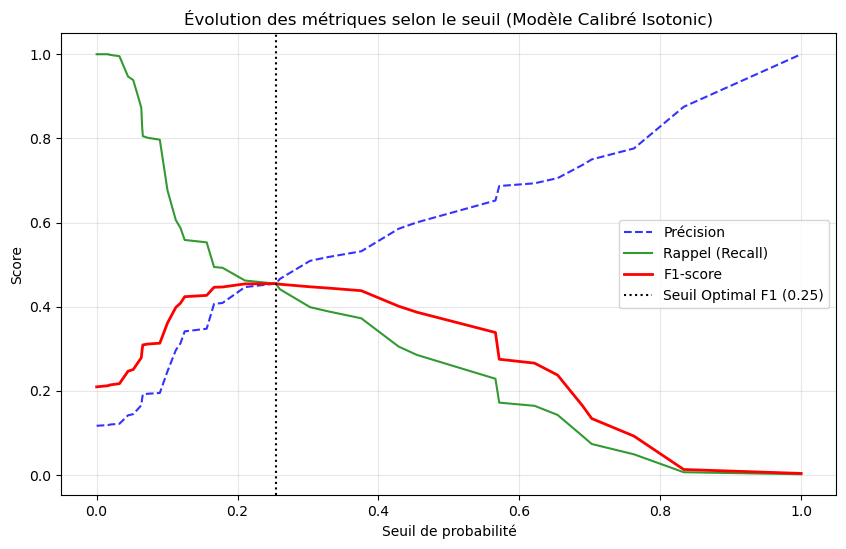

Le seuil qui maximise le F1-score est : 0.2545

--- Tableau de performance finale sur Validation (Optimisé + Calibré) ---


,roc_auc,pr_auc,brier,f1,recall,precision,threshold
0,0.777841,0.409582,0.083697,0.454846,0.454631,0.455061,0.254545


In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, proba_val_calibrated_iso)

#Calcul du F1-score pour chaque seuil pour trouver le compromis optimal
# On ajoute une petite valeur (1e-10) pour éviter la division par zéro
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Précision", alpha=0.8)
plt.plot(thresholds, recalls[:-1], "g-", label="Rappel (Recall)", alpha=0.8)
plt.plot(thresholds, f1_scores[:-1], "r-", lw=2, label="F1-score")

plt.axvline(x=best_threshold, color='black', linestyle=':', label=f'Seuil Optimal F1 ({best_threshold:.2f})')
plt.xlabel("Seuil de probabilité")
plt.ylabel("Score")
plt.title("Évolution des métriques selon le seuil (Modèle Calibré Isotonic)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Le seuil qui maximise le F1-score est : {best_threshold:.4f}")

final_val_perf = evaluate_probas(y_val, proba_val_calibrated_iso, threshold=best_threshold)
print("\n--- Tableau de performance finale sur Validation (Optimisé + Calibré) ---")
display(pd.DataFrame([final_val_perf]))

En changeant le seuil à 0,25 (au lieu de 0,5) :

Équilibre parfait : la précision et le rappel sont désormais presque identiques (environ 45 % chacun).

Qualité des appels : on est passés de 27 % à 45 % de précision. Cela signifie que presque un appel sur deux sera fructueux, contre un sur quatre auparavant.

Fiabilité : Avec le score de Brier le plus bas (0,0837), on a maintenant un modèle "honnête" statistiquement.

# IV. L'Évaluation Finale (Test Set)


--- COMPARAISON FINALE SUR LE TEST SET ---


,Stratégie,roc_auc,pr_auc,brier,f1,recall,precision,threshold
0,"Baseline (C=1, Seuil=0.5, Non-Calibré)",0.771869,0.411788,0.182940,0.380634,0.646503,0.269716,0.500000
1,"Final (C=0.1, Seuil=0.25, Calibré Iso)",0.770749,0.394625,0.084874,0.446565,0.442344,0.450867,0.254545


<Figure size 800x600 with 0 Axes>

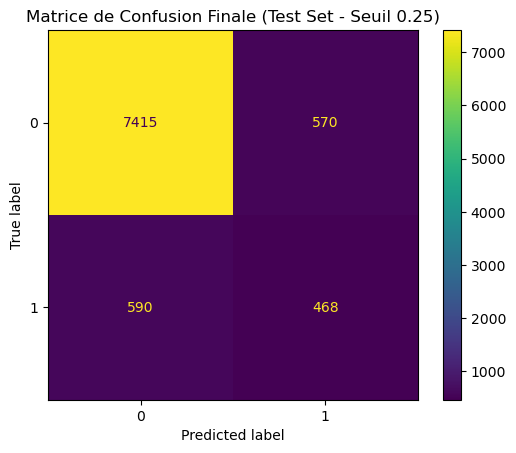

In [12]:
# 1. Prédictions finales sur le Test Set (modèle calibré Isotonic)
proba_test_final = calibrated_logreg_iso.predict_proba(X_test_final)[:, 1]

# 2. Calcul des performances avec le seuil optimisé (0.2545)
perf_test_final = evaluate_probas(y_test, proba_test_final, threshold=best_threshold)

# 3. Comparaison finale : Baseline vs Modèle Final (sur le Test Set)
print("\n--- COMPARAISON FINALE SUR LE TEST SET ---")
final_comparison = pd.DataFrame([
    {"Stratégie": "Baseline (C=1, Seuil=0.5, Non-Calibré)", **evaluate_probas(y_test, proba_test, 0.5)},
    {"Stratégie": f"Final (C=0.1, Seuil={best_threshold:.2f}, Calibré Iso)", **perf_test_final}
])
display(final_comparison)

# 4. Matrice de confusion finale
from sklearn.metrics import ConfusionMatrixDisplay
y_test_pred = (proba_test_final >= best_threshold).astype(int)

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.title(f"Matrice de Confusion Finale (Test Set - Seuil {best_threshold:.2f})")
plt.show()

En ajustant le seuil à 0.25, nous avons divisé le nombre de faux positifs par plus de trois (passant de 1867 sur la validation à seulement 570 sur le test).